In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

In [47]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, average_precision_score
from sklearn.model_selection import train_test_split

In [5]:
df = pd.read_csv("candidates.csv")

In [6]:
df.head()

,seriesuid,coordX,coordY,coordZ,class
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-56.08,-67.85,-311.92,0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,53.21,-244.41,-245.17,0
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.66,-121.80,-286.62,0
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-33.66,-72.75,-308.41,0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-32.25,-85.36,-362.51,0


In [7]:
# plt.figure(figsize=(8,6))
# plt.scatter(df[df['class']==0]['coordX'], df[df['class']==0]['coordY'],
#             color='blue', label='Not Nodule (0)', alpha=0.5)
# plt.scatter(df[df['class']==1]['coordX'], df[df['class']==1]['coordY'],
#             color='red', label='Nodule (1)', alpha=0.5)

# plt.xlabel("coordX")
# plt.ylabel("coordY")
# plt.title("LUNA16 Candidates: coordX vs coordY")
# plt.legend()
# plt.show()

In [8]:
# fig = plt.figure(figsize=(8,6))
# ax = fig.add_subplot(111, projection='3d')

# ax.scatter(df[df['class']==0]['coordX'], 
#            df[df['class']==0]['coordY'], 
#            df[df['class']==0]['coordZ'],
#            color='blue', label='Not Nodule (0)', alpha=0.5)

# ax.scatter(df[df['class']==1]['coordX'], 
#            df[df['class']==1]['coordY'], 
#            df[df['class']==1]['coordZ'],
#            color='red', label='Nodule (1)', alpha=0.5)

# ax.set_xlabel("coordX")
# ax.set_ylabel("coordY")
# ax.set_zlabel("coordZ")
# ax.set_title("3D Scatter Plot of Candidates")
# ax.legend()
# plt.show()

In [9]:
X = df[['coordX','coordY','coordZ']]
y = df['class']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

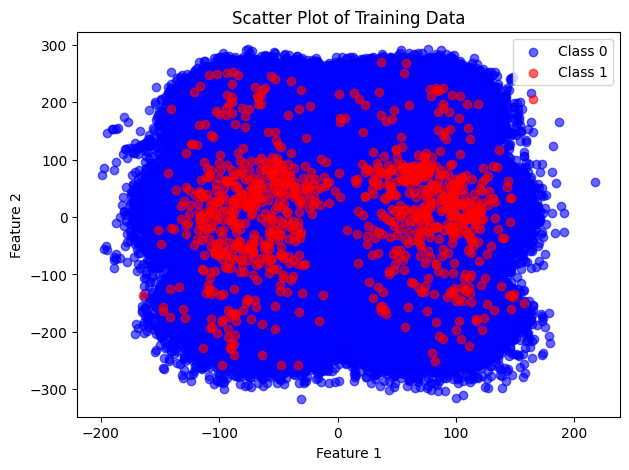

In [11]:
X_np = X_train.to_numpy()
y_np = y_train.to_numpy()

plt.figure(figsize=(7,5))
plt.scatter(X_np[y_np==0, 0], X_np[y_np==0, 1],
            color='blue', label='Class 0', alpha=0.6)
plt.scatter(X_np[y_np==1, 0], X_np[y_np==1, 1],
            color='red', label='Class 1', alpha=0.6)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scatter Plot of Training Data")
plt.legend()
plt.show()

In [12]:
lr = LogisticRegression()
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [13]:
y_pred = lr.predict(X_test)
print(classification_report(y_test,y_pred))
confusion_matrix(y_test,y_pred)
print("roc_auc_score",roc_auc_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    164915
           1       0.00      0.00      0.00       405

    accuracy                           1.00    165320
   macro avg       0.50      0.50      0.50    165320
weighted avg       1.00      1.00      1.00    165320

roc_auc_score 0.5


In [14]:
from imblearn.under_sampling import RandomUnderSampler

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_train,y_train)

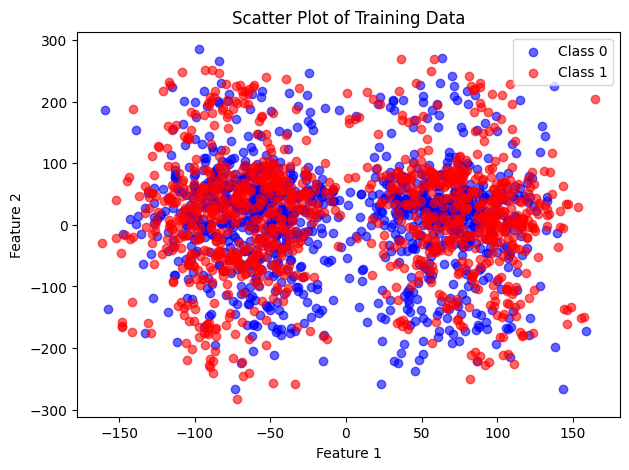

In [17]:
X_np = X_res.to_numpy()
y_np = y_res.to_numpy()

plt.figure(figsize=(7,5))
plt.scatter(X_np[y_np==0, 0], X_np[y_np==0, 1],
            color='blue', label='Class 0', alpha=0.6)
plt.scatter(X_np[y_np==1, 0], X_np[y_np==1, 1],
            color='red', label='Class 1', alpha=0.6)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scatter Plot of Training Data")
plt.legend()
plt.show()

In [18]:
pd.Series(y_train).value_counts()

class
0    439788
1      1064
Name: count, dtype: int64

In [19]:
pd.Series(y_res).value_counts()

class
0    1064
1    1064
Name: count, dtype: int64

In [20]:
lr1 = LogisticRegression()
lr1.fit(X_res,y_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
y_pred = lr1.predict(X_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print("roc_auc_score",roc_auc_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.45      0.62    109926
           1       0.00      0.52      0.00       287

    accuracy                           0.45    110213
   macro avg       0.50      0.48      0.31    110213
weighted avg       0.99      0.45      0.62    110213

[[49842 60084]
 [  139   148]]
roc_auc_score 0.484546778729384


In [22]:
clf = LogisticRegression(class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [23]:
y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print("roc_auc_score",roc_auc_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.51      0.67    109926
           1       0.00      0.44      0.00       287

    accuracy                           0.51    110213
   macro avg       0.50      0.48      0.34    110213
weighted avg       0.99      0.51      0.67    110213

[[55873 54053]
 [  160   127]]
roc_auc_score 0.47539350355490967


In [24]:
from imblearn.over_sampling import RandomOverSampler

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
ros = RandomOverSampler(random_state=42)
X_res1, y_res1 = ros.fit_resample(X_train, y_train)

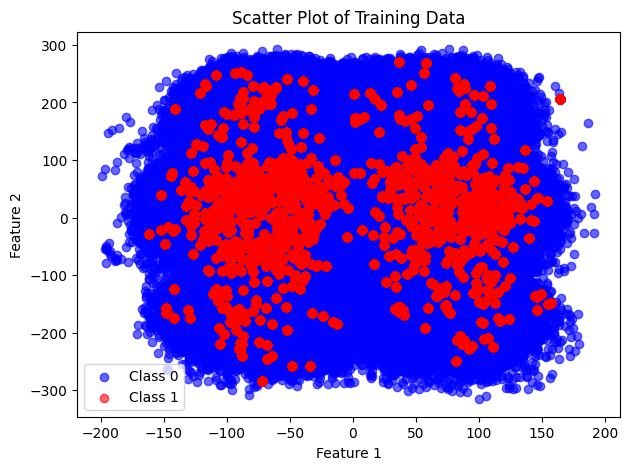

In [27]:
X_np = X_res1.to_numpy()
y_np = y_res1.to_numpy()

plt.figure(figsize=(7,5))
plt.scatter(X_np[y_np==0, 0], X_np[y_np==0, 1],
            color='blue', label='Class 0', alpha=0.6)
plt.scatter(X_np[y_np==1, 0], X_np[y_np==1, 1],
            color='red', label='Class 1', alpha=0.6)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scatter Plot of Training Data")
plt.legend()
plt.show()

In [28]:
pd.Series(y_train).value_counts()

class
0    439788
1      1064
Name: count, dtype: int64

In [29]:
pd.Series(y_res1).value_counts()

class
0    439788
1    439788
Name: count, dtype: int64

In [30]:
lr2 = LogisticRegression()
lr2.fit(X_res1,y_res1)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [31]:
y_pred = lr2.predict(X_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print("roc_auc_score",roc_auc_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.51      0.67    109926
           1       0.00      0.44      0.00       287

    accuracy                           0.51    110213
   macro avg       0.50      0.48      0.34    110213
weighted avg       0.99      0.51      0.67    110213

[[55945 53981]
 [  160   127]]
roc_auc_score 0.4757209965956826


In [32]:
from imblearn.over_sampling import SMOTE

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
X_resampled_smote, y_resampled_smote = smote.fit_resample(X_train, y_train)

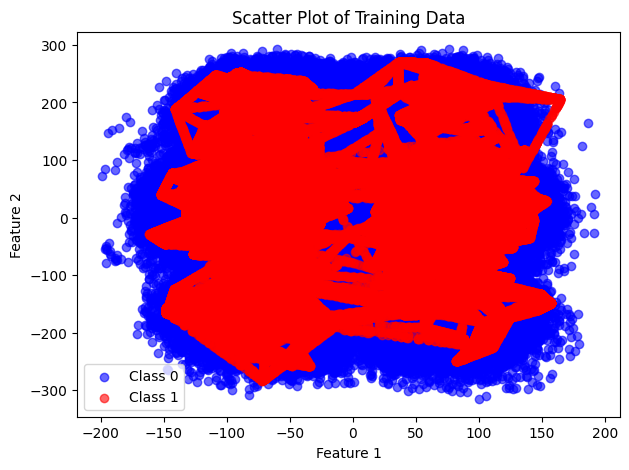

In [34]:
X_np = X_resampled_smote.to_numpy()
y_np = y_resampled_smote.to_numpy()

plt.figure(figsize=(7,5))
plt.scatter(X_np[y_np==0, 0], X_np[y_np==0, 1],
            color='blue', label='Class 0', alpha=0.6)
plt.scatter(X_np[y_np==1, 0], X_np[y_np==1, 1],
            color='red', label='Class 1', alpha=0.6)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scatter Plot of Training Data")
plt.legend()
plt.show()

In [35]:
pd.Series(y_train).value_counts()

class
0    439788
1      1064
Name: count, dtype: int64

In [36]:
pd.Series(y_resampled_smote).value_counts()

class
0    439788
1    439788
Name: count, dtype: int64

In [37]:
lr3 = LogisticRegression()
lr3.fit(X_resampled_smote,y_resampled_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [38]:
y_pred = lr3.predict(X_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print("roc_auc_score",roc_auc_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.51      0.67    109926
           1       0.00      0.44      0.00       287

    accuracy                           0.51    110213
   macro avg       0.50      0.48      0.34    110213
weighted avg       0.99      0.51      0.67    110213

[[56071 53855]
 [  160   127]]
roc_auc_score 0.4762941094170351


In [39]:
from sklearn.ensemble import RandomForestClassifier

In [65]:
rf = RandomForestClassifier(class_weight={0:1, 1:50},n_jobs=-1,random_state=42, n_estimators=100)
rf3 = RandomForestClassifier(class_weight={0:1, 1:50},n_jobs=-1, random_state=42, n_estimators=100)
rf2 = RandomForestClassifier(class_weight={0:1, 1:50},n_jobs=-1, random_state=42, n_estimators=100)
rf1 = RandomForestClassifier(class_weight={0:1, 1:50},n_jobs=-1, random_state=42, n_estimators=100)

In [66]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [67]:
rf3.fit(X_res, y_res)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [68]:
rf2.fit(X_res1, y_res1)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [69]:
rf1.fit(X_resampled_smote, y_resampled_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))
print("PR AUC:", average_precision_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    109926
           1       0.00      0.00      0.00       287

    accuracy                           1.00    110213
   macro avg       0.50      0.50      0.50    110213
weighted avg       0.99      1.00      1.00    110213

ROC AUC: 0.5
PR AUC: 0.0026040485242212804


In [71]:
y_pred = rf1.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))
print("PR AUC:", average_precision_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98    109926
           1       0.01      0.08      0.01       287

    accuracy                           0.96    110213
   macro avg       0.50      0.52      0.50    110213
weighted avg       0.99      0.96      0.98    110213

ROC AUC: 0.5213070642835367
PR AUC: 0.0028397217797889633


In [72]:
y_pred = rf2.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))
print("PR AUC:", average_precision_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    109926
           1       0.00      0.00      0.00       287

    accuracy                           1.00    110213
   macro avg       0.50      0.50      0.50    110213
weighted avg       0.99      1.00      1.00    110213

ROC AUC: 0.4999954514855448
PR AUC: 0.0026040485242212804


In [73]:
y_pred = rf3.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))
print("PR AUC:", average_precision_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.64      0.78    109926
           1       0.00      0.60      0.01       287

    accuracy                           0.64    110213
   macro avg       0.50      0.62      0.39    110213
weighted avg       1.00      0.64      0.77    110213

ROC AUC: 0.6176336649913553
PR AUC: 0.0036083184831541904
